### Implementing Simple self rag

In this part, we implement self rag which first helps us to understand whether to retrieve the docs or not based on the queries that we get

In [2]:
import sys
!{sys.executable} -m pip install langchain langchain-community langchain-openai langgraph python-dotenv langchain-text-splitters pypdf

from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.0/346.0 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


/tmp/ipykernel_3286/3734924684.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


False

In [3]:
docs = (
    PyPDFLoader("./Company_Policies.pdf").load()
    + PyPDFLoader("./Company_Profile.pdf").load()
    + PyPDFLoader("./Product_and_Pricing.pdf").load()
)

In [4]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [5]:
!pip install langchain-huggingface sentence-transformers

In [6]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
pip install faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 9.3 MB/s eta 0:00:00


In [8]:
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [ ]:
import os
os.environ["GROQ_API_KEY"] = "your-groq-key"

In [10]:
!pip install -q langchain-groq
from langchain_groq import ChatGroq

llm = ChatGroq(model_name="llama-3.3-70b-versatile",
temperature=0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 2.2 MB/s eta 0:00:00


State has the following things,
1. Question to store the question as string
2. Then, needs retrieval to see whether the query needs docs or not, thus in bool
3. list of fetched docs(if any)
4. answer in the form of string

In [11]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]

    answer: str

We make a retreive class and provide should_retrieve as field returning bool. The ... signifies required and description to understand

1. After that we chain it together
2. Then in decide retrieval we tend to decide whether needed or not

In [12]:
from pydantic import BaseModel, Field

class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [13]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }

In [14]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

Here, we make the routing working. Where if needs retrieval we route to retrieve node else we directly o/p via llm

In [15]:
from typing import Literal

def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

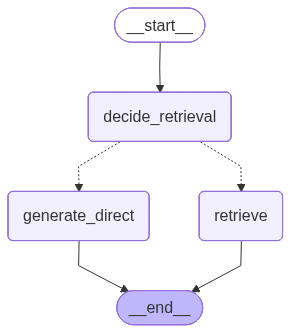

In [16]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)
g.add_edge("retrieve", END)  # temporary END for retrieval path

app = g.compile()
app

In [17]:
result = app.invoke(
    {
        "question": "What is Machine Learning",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

Machine Learning (ML) is a subset of Artificial Intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform tasks without being explicitly programmed. In other words, ML allows computers to learn from data and improve their performance on a task over time, without being explicitly told what to do.

The key characteristics of Machine Learning are:

1. **Learning from data**: ML algorithms learn from data, which can be in the form of images, text, audio, or other types of data.
2. **Improving performance**: As the algorithm learns from the data, it improves its performance on the task it is designed to perform.
3. **No explicit programming**: The algorithm is not explicitly programmed to perform the task, but rather learns to perform the task through experience.

There are several types of Machine Learning, including:

1. **Supervised Learning**: The algorithm is trained on labeled data, where the correct output is already known.
2. **Unsupe

In [18]:
result['need_retrieval']

False

In [19]:
result['docs']

[]

### Filtering relevant docs

In [20]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]     # New

    answer: str

Here, we do the following things,
1. We make the relevance decision class
2. Then we promot and invoke the llm
3. After that, by structured o/p we pass the schema to the llm
4. Then we invoke llm for each document and if relevant then we store in state

In [21]:
# New

class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):

    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

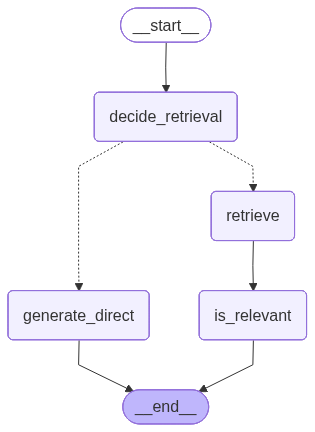

In [22]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant) # New

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)
g.add_edge("retrieve", "is_relevant") # New
g.add_edge("is_relevant", END) # New

app = g.compile()
app

Currently, we arent generating answers so we arent getting any answer. This would be done ahead

In [25]:
result = app.invoke(
    {
        "question": "Who is the CEO of NexaAI",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

In [24]:
result['need_retrieval']

True

This is the total docs that the retriever fetched

In [26]:
for doc in result['docs']:
    print(doc.page_content)
    print("*"*100)

Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Founder

Riya Kapoor – CTO (Distributed systems & AI platforms)

Kunal Sharma – Head of Product

Neha Verma – Head of Operations & HR

Siddharth Rao – Head of Sales & Partnerships
****************************************************************************************************
NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
The company specializes in building enterprise-ready AI systems for knowledge management,
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations acros

This is are the ones which are actually relevant

In [27]:
for doc in result['relevant_docs']:
    print(doc.page_content)
    print("*"*100)

Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Founder

Riya Kapoor – CTO (Distributed systems & AI platforms)

Kunal Sharma – Head of Product

Neha Verma – Head of Operations & HR

Siddharth Rao – Head of Sales & Partnerships
****************************************************************************************************


### Generating answers from context

In the state we add context too

In [28]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]

    context: str # New
    answer: str

Basis code for rag

In [29]:
# New
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.", "context": ""}

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {"answer": out.content, "context": context}

New node definition if we dont relevant doc and routing for the 3rd part that is after relevant in the graph

In [30]:
# New
def no_relevant_docs(state: State):
    return {"answer": "No relevant document found.", "context": ""}

In [31]:
# New
def route_after_relevance(state: State) -> Literal["generate_from_context", "no_relevant_docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "no_relevant_docs"

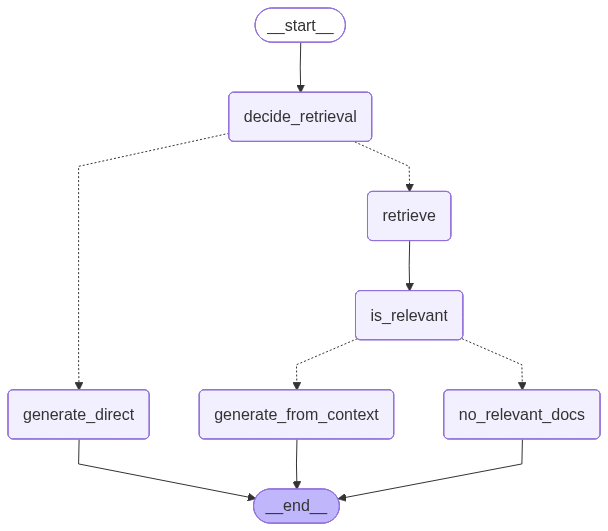

In [32]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_relevant_docs", no_relevant_docs)

g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "no_relevant_docs": "no_relevant_docs",
    },
)

g.add_edge("generate_from_context", END)
g.add_edge("no_relevant_docs", END)

app = g.compile()

app

In [33]:
result = app.invoke(
    {
        "question": "What is the refund policy of NexaAI",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
    }
)

print(result["answer"])

No relevant document found.


In [35]:
for doc in result['relevant_docs']:
    print(doc.page_content)
    print("*"*100)

### Detecting hallucinations aka support node

We see for the support of docs via deciding upto what extent is that supported

In [36]:
# -----------------------------
# Graph State
# -----------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str

    # Post-generation verification
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

In [37]:
# -----------------------------
# 6) IsSUP verify + revise loop
# -----------------------------
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)



issup_llm = llm.with_structured_output(IsSUPDecision)

def is_sup(state: State):
    decision: IsSUPDecision = issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {"issup": decision.issup, "evidence": decision.evidence}

In [39]:

def no_answer_found(state: State):
    return {"answer": "No answer found.", "context": ""}

In [46]:
# New
def route_after_relevance(state: State) -> Literal["generate_from_context", "no_answer_found"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "no_answer_found"

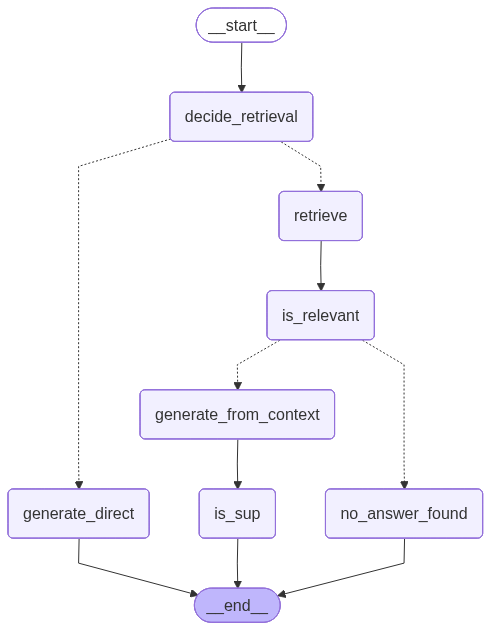

In [47]:
# -----------------------------
# Build graph
# -----------------------------
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_answer_found", no_answer_found)

g.add_node("is_sup", is_sup)

g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {"generate_direct": "generate_direct", "retrieve": "retrieve"},
)

g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {"generate_from_context": "generate_from_context", "no_answer_found": "no_answer_found"},
)

# If no answer found, end
g.add_edge("no_answer_found", END)

# If generated from context, verify with IsSUP loop
g.add_edge("generate_from_context", "is_sup")
g.add_edge("is_sup", END)

app = g.compile()
app

In [48]:
result = app.invoke(
        {
            "question": 'Do NexaAI plans include a free trial? If yes, how many days?',
            "docs": [],
            "relevant_docs": [],
            "context": "",
            "answer": "",
            "issup": "",
            "evidence": [],
        },
    )

print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 0
issup: 
evidence: []
answer: No answer found.


### Revised Answer Loop

In the state we define new variable retries as integer

In [49]:
# -----------------------------
# Graph State
# -----------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str

    # Post-generation verification
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    # ✅ NEW
    retries: int

In [50]:
def accept_answer(state: State):
    return {}  # keep answer as-is

In [51]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)



def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # ✅ increment
    }

In [56]:
MAX_RETRIES = 10

In [57]:
def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    # accept if fully supported
    if state.get("issup") == "fully_supported":
        return "accept_answer"

    # stop if we've already tried enough
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"   # or return a "give_up" node if you want

    # otherwise revise again
    return "revise_answer"

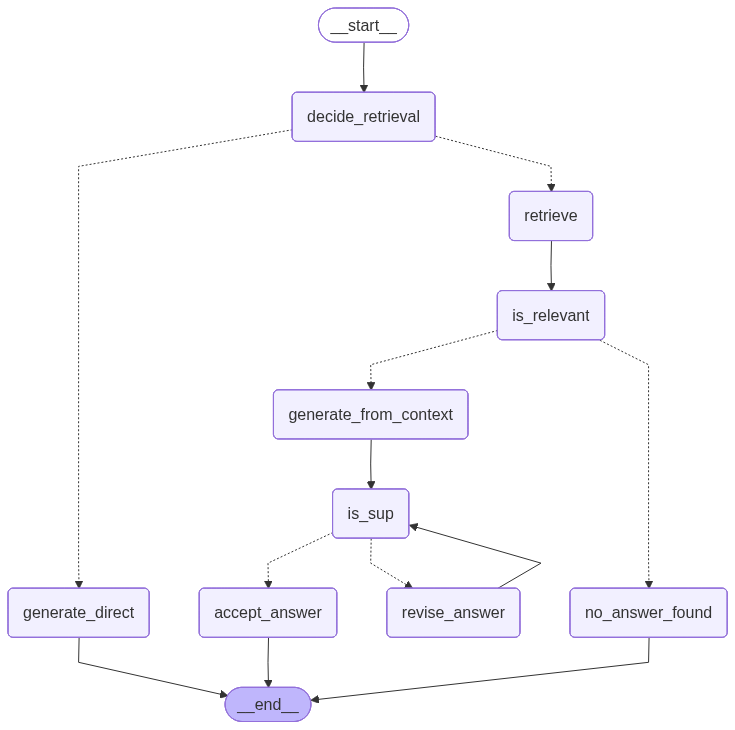

In [58]:
# -----------------------------
# Build graph (REVISED: add accept/revise + loop back to is_sup)
# -----------------------------
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_answer_found", no_answer_found)

g.add_node("is_sup", is_sup)

# ✅ NEW nodes
g.add_node("accept_answer", accept_answer)
g.add_node("revise_answer", revise_answer)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {"generate_direct": "generate_direct", "retrieve": "retrieve"},
)

g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {"generate_from_context": "generate_from_context", "no_answer_found": "no_answer_found"},
)

# If no answer found, end
g.add_edge("no_answer_found", END)

# --------------------
# Verify → (accept | revise) → verify loop
# --------------------
g.add_edge("generate_from_context", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,  # fully_supported -> accept_answer else revise_answer
    {"accept_answer": "accept_answer", "revise_answer": "revise_answer"},
)

g.add_edge("revise_answer", "is_sup")  # 🔁 loop back to verify
g.add_edge("accept_answer", END)

app = g.compile()
app

In [59]:
result = app.invoke(
    {
        "question": "Describe NexaAI’s company culture.",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "issup": "",
        "evidence": [],
        "retries": 0,
    },
    config={"recursion_limit": 80},  # ✅ bump limit
)



print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 1
issup: fully_supported
evidence: ['NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.', 'Employees are encouraged to maintain a healthy work-life balance.', 'All employment decisions are made without discrimination.']
answer: - NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
- Employees are encouraged to maintain a healthy work-life balance.


In [60]:
print(result.get("retries"))

1


In [61]:
for doc in result['relevant_docs']:
    print(doc.page_content)

NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms



### Testing answer usefullness and query rewriting

In [62]:
class State(TypedDict):
    question: str
    need_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str

    # Post-generation verification
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

    # ✅ NEW: usefulness check
    isuse: Literal["useful", "not_useful"]
    use_reason: str

In [63]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm = llm.with_structured_output(IsUSEDecision)

def is_use(state: State):
    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
        )
    )
    return {"isuse": decision.isuse, "use_reason": decision.reason}


def route_after_isuse(state: State) -> Literal["END", "no_answer_found"]:
    if state.get("isuse") == "useful":
        return "END"
    return "no_answer_found"

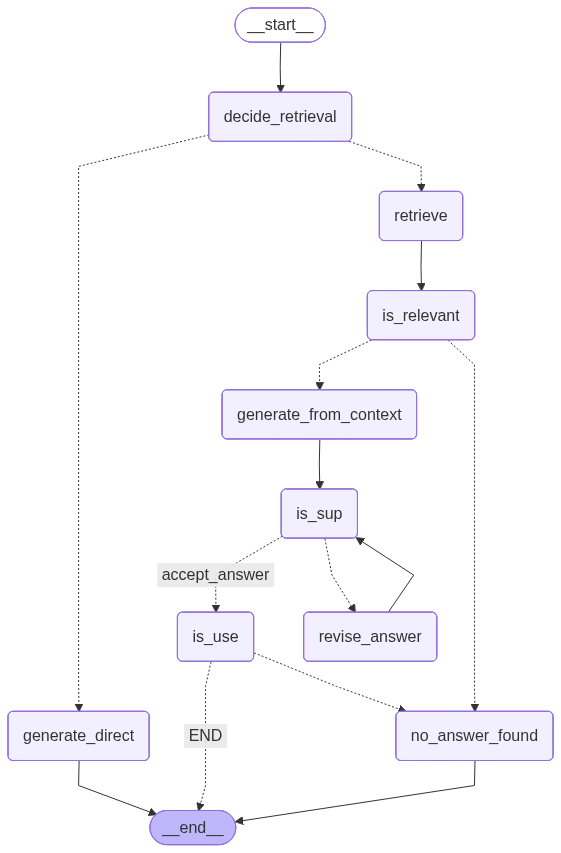

In [64]:
# -----------------------------
# Build graph (UPDATED: IsUSE inserted after IsSUP)
# -----------------------------
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_answer_found", no_answer_found)

# IsSUP + revise loop
g.add_node("is_sup", is_sup)
g.add_node("revise_answer", revise_answer)

# ✅ NEW: IsUSE + finalize
g.add_node("is_use", is_use)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {"generate_direct": "generate_direct", "retrieve": "retrieve"},
)

g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "no_answer_found": "no_answer_found",
    },
)

# If no answer found, end
g.add_edge("no_answer_found", END)

# --------------------
# Generate -> IsSUP -> (IsUSE | revise) loop
# --------------------
g.add_edge("generate_from_context", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,
    {
        "accept_answer": "is_use",      # ✅ fully_supported goes to IsUSE
        "revise_answer": "revise_answer",
    },
)

# revise then re-check support
g.add_edge("revise_answer", "is_sup")  # 🔁 loop back to IsSUP

# --------------------
# IsUSE routing
# --------------------
g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "END": END,
        "no_answer_found": "no_answer_found",
    },
)

app = g.compile()
app

In [65]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "What is refund policy of NexaAI",
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
}

result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state["question"])
print("Need Retrieval:", result.get("need_retrieval"))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", [])))
print("  Relevant docs:", len(result.get("relevant_docs", [])))

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
print("  evidence:")
for e in result.get("evidence", []):
    print("   -", e)

print("Final Answer:", result.get("answer"))
print("Usefulness Status - ", result.get("isuse"))
print("Usefulness Reason ", result.get("use_reason"))

print("\nRetries used:", result.get("retries", 0))
print("\n===============================\n")


===== RAG EXECUTION RESULT =====

Question: What is refund policy of NexaAI
Need Retrieval: True

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 0

Verification (IsSUP):
  issup: 
  evidence:
Final Answer: No answer found.
Usefulness Status -  None
Usefulness Reason  None

Retries used: 0




### Rewriting Query

In [66]:
# -----------------------------
class State(TypedDict):
    question: str

    # ✅ NEW: what we actually send to vector retriever
    retrieval_query: str
    rewrite_tries: int

    need_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str

    # Post-generation verification
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

    isuse: Literal["useful", "not_useful"]
    use_reason: str

In [67]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm = llm.with_structured_output(IsUSEDecision)

def is_use(state: State):
    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
        )
    )
    return {"isuse": decision.isuse, "use_reason": decision.reason}

MAX_REWRITE_TRIES = 3  # tune (2–4 is usually fine)

def route_after_isuse(state: State) -> Literal["END", "rewrite_question", "no_answer_found"]:
    if state.get("isuse") == "useful":
        return "END"

    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "no_answer_found"

    return "rewrite_question"

In [68]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)



rewrite_llm = llm.with_structured_output(RewriteDecision)

def rewrite_question(state: State):
    decision: RewriteDecision = rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["question"],
            retrieval_query=state.get("retrieval_query", ""),
            answer=state.get("answer", ""),
        )
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        # ✅ optional: reset these so next pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }

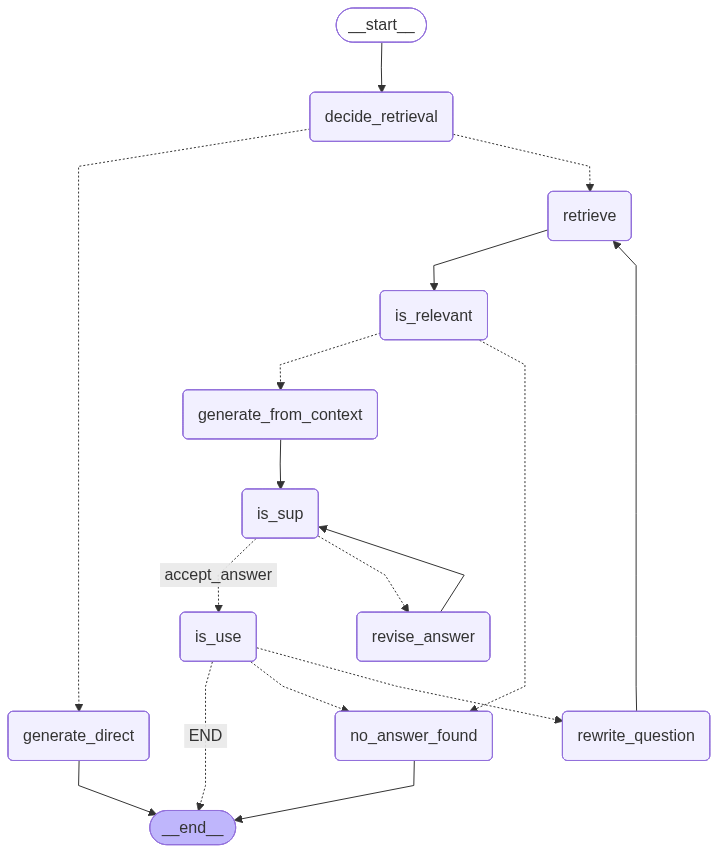

In [69]:
# -----------------------------
# Build graph (UPDATED: IsUSE -> if not useful -> rewrite -> retrieve; else END)
# -----------------------------
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_answer_found", no_answer_found)

# IsSUP + revise loop
g.add_node("is_sup", is_sup)
g.add_node("revise_answer", revise_answer)

# IsUSE
g.add_node("is_use", is_use)

# ✅ NEW: rewrite question for better retrieval
g.add_node("rewrite_question", rewrite_question)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {"generate_direct": "generate_direct", "retrieve": "retrieve"},
)

g.add_edge("generate_direct", END)

# Retrieve -> relevance -> (generate | no_answer_found)
g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "no_answer_found": "no_answer_found",
    },
)

g.add_edge("no_answer_found", END)

# --------------------
# Generate -> IsSUP -> (IsUSE | revise) loop
# --------------------
g.add_edge("generate_from_context", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,
    {
        "accept_answer": "is_use",      # fully_supported (or max retries) -> go to IsUSE
        "revise_answer": "revise_answer",
    },
)

g.add_edge("revise_answer", "is_sup")  # 🔁 loop back to IsSUP

# --------------------
# IsUSE routing
#   - useful -> END
#   - not_useful -> rewrite_question -> retrieve (try again)
#   - give up -> no_answer_found -> END
# --------------------
g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "END": END,
        "rewrite_question": "rewrite_question",
        "no_answer_found": "no_answer_found",
    },
)

# rewrite -> retrieve -> relevance -> ...
g.add_edge("rewrite_question", "retrieve")

app = g.compile()
app

In [70]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "Describe NexaAI’s company culture.",
    "retrieval_query": "What is the refund policy of NexaAI",  # ✅ important
    "rewrite_tries": 0,                                        # ✅ important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "not_useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")


===== RAG EXECUTION RESULT =====

Question: Describe NexaAI’s company culture.
Need Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 1

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 1

Relevant docs (source/page):
  1. source=./Company_Policies.pdf, page=0, title=(anonymous)

Verification (IsSUP):
  issup: fully_supported
  evidence:
   - NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
   - Employees are encouraged to maintain a healthy work-life balance.
   - All employment decisions are made without discrimination.

Usefulness (IsUSE):
  isuse: useful
  reason: Answer directly describes company culture

Final Answer:
- NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
- Employees are encouraged to maintain a healthy work-life balance.


